In [129]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
%matplotlib notebook
%matplotlib inline
from sklearn import svm, metrics, datasets
from sklearn.utils import Bunch
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from skimage.io import imread
from skimage.transform import resize
import skimage.io # Import the skimage module
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:

image_folder = "/content/drive/MyDrive/images/images"  # Path to the image folder
categories = os.listdir(image_folder)  # Get the list of categories

for category in categories:
  category_path = os.path.join(image_folder, category)
  for image_file in os.listdir(category_path):
    image_path = os.path.join(category_path, image_file)
    # Process the image file (e.g., read using OpenCV or Pillow)

In [131]:
def load_image_files(container_path, dimension=(64, 64)):
    """
    Load image files with categories as subfolder names
    which performs like scikit-learn sample dataset

    Parameters
    ----------
    container_path : string or unicode
        Path to the main folder holding one subfolder per category
    dimension : tuple
        size to which image are adjusted to

    Returns
    -------
    Bunch
    """
    image_dir = Path(container_path)
    folders = [directory for directory in image_dir.iterdir() if directory.is_dir()]
    categories = [fo.name for fo in folders]

    descr = "A image classification dataset"
    images = []
    flat_data = []
    target = []
    for i, direc in enumerate(folders):
        for file in direc.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)
    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(data=flat_data,
                 target=target,
                 target_names=categories,
                 images=images,
                 DESCR=descr)

In [132]:
image_dataset = load_image_files("/content/drive/MyDrive/images/images")

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data, image_dataset.target, test_size=0.3, random_state=42
)

In [134]:
def predict_new_image(img_path, dimension=(64,64)):
    img = skimage.io.imread(img_path)
    img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
    flat = img_resized.flatten().reshape(1, -1)
    pred = best_rf.predict(flat)
    return image_dataset.target_names[pred[0]]

In [149]:
print(predict_new_image("/content/drive/MyDrive/test_images/image01.jpg"))
#should predict pizza

pizza


In [136]:
print(predict_new_image("/content/drive/MyDrive/test_images/image02.jpg"))
#should predict dalmation

dalmatian


In [137]:
print(predict_new_image("/content/drive/MyDrive/test_images/image03.jpg"))
#should predict dollar bill

dollar_bill


In [153]:
print(predict_new_image("/content/drive/MyDrive/test_images/image04.jpg"))
#should predict soccer ball

pizza


In [139]:
print(predict_new_image("/content/drive/MyDrive/test_images/image05.jpg"))
#should predict sunflower

sunflower


In [140]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier()
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [141]:
rf_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Accuracy: 0.6774193548387096
Precision: 0.6879104410230613
Recall: 0.6774193548387096
F1 Score: 0.6790870829093593

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.57      0.65        21
           1       0.72      0.72      0.72        18
           2       0.47      0.56      0.51        16
           3       0.81      0.85      0.83        26
           4       0.54      0.58      0.56        12

    accuracy                           0.68        93
   macro avg       0.66      0.66      0.66        93
weighted avg       0.69      0.68      0.68        93



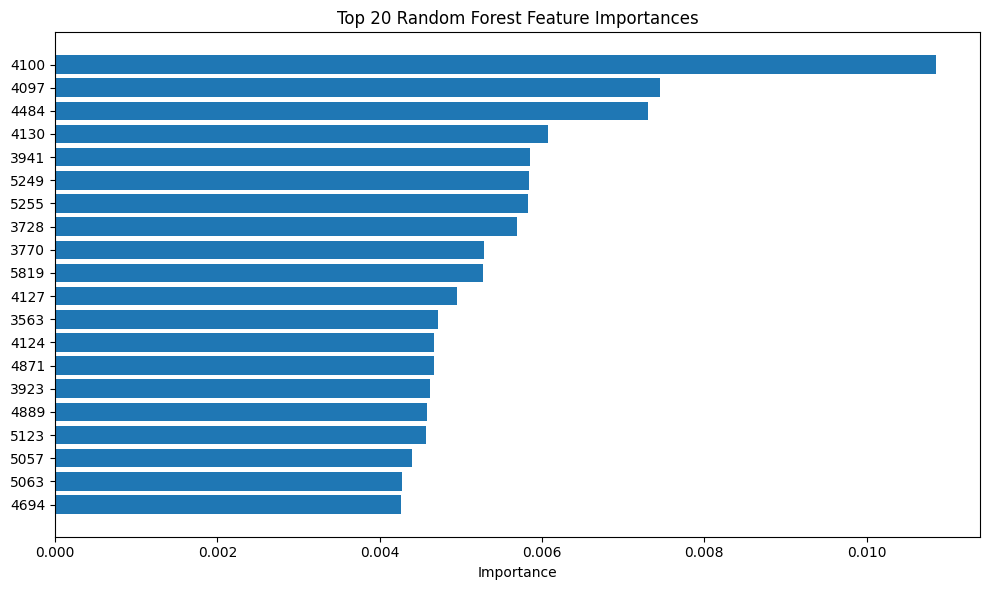

In [142]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [143]:
svc_param_grid = [
    {'C': [1, 10, 100], 'kernel': ['linear']},
    {'C': [1, 10, 100], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}
]

svc = svm.SVC()
svc_grid = GridSearchCV(svc, svc_param_grid, cv=3, n_jobs=-1)
svc_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [1, 10, 100], 'kernel': ['linear']},
                         {'C': [1, 10, 100], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}])

In [144]:
print(svc_grid.best_params_)

{'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}


In [145]:
svc_pred = svc_grid.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svc_pred))
print("SVM Classification Report:\n", classification_report(y_test, svc_pred))

SVM Accuracy: 0.7204301075268817
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.67      0.61        21
           1       0.68      0.72      0.70        18
           2       0.64      0.44      0.52        16
           3       0.89      0.96      0.93        26
           4       0.80      0.67      0.73        12

    accuracy                           0.72        93
   macro avg       0.71      0.69      0.70        93
weighted avg       0.72      0.72      0.72        93



In [146]:
y_pred = svc_grid.predict(X_test)

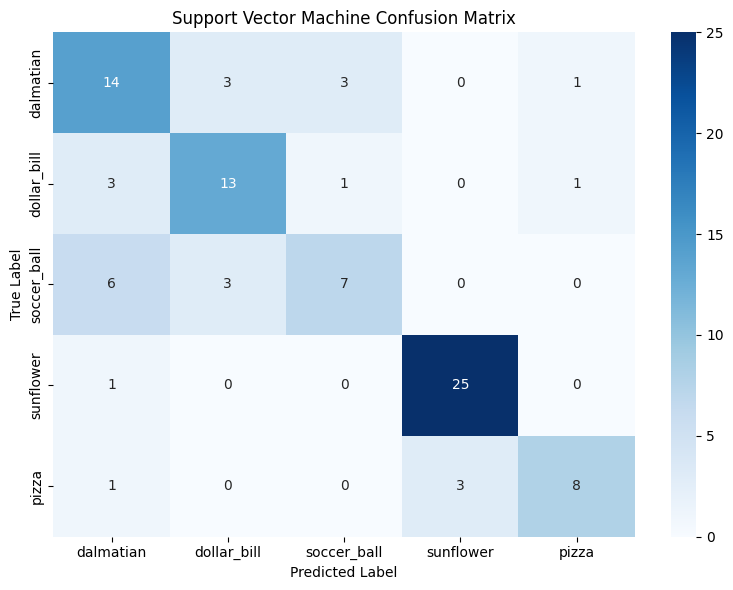

In [147]:
cm_svc = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=image_dataset.target_names,
    yticklabels=image_dataset.target_names
)

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [148]:
print("Classification report for - \n{}:\n{}\n".format(
    svc_grid, metrics.classification_report(y_test, y_pred)))

Classification report for - 
GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [1, 10, 100], 'kernel': ['linear']},
                         {'C': [1, 10, 100], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}]):
              precision    recall  f1-score   support

           0       0.56      0.67      0.61        21
           1       0.68      0.72      0.70        18
           2       0.64      0.44      0.52        16
           3       0.89      0.96      0.93        26
           4       0.80      0.67      0.73        12

    accuracy                           0.72        93
   macro avg       0.71      0.69      0.70        93
weighted avg       0.72      0.72      0.72        93


